# FEMT-Net Notebook Implementation

## Federated Explainable Multimodal Transformer Network for Cardiovascular Disease Prediction

This notebook is rewritten to match the document architecture and now implements a multimodal pipeline built around:
1. **Raw ECG waveform input**
2. **Clinical feature encoding**
3. **CNN-based ECG representation learning**
4. **Transformer-based multimodal fusion**
5. **Federated learning with weighted FedAvg**
6. **Explainable AI using SHAP, modality attention, and ECG saliency maps**

**Primary Goal:** Predict cardiovascular disease from ECG signals and clinical data while preserving privacy in multi-hospital settings.

---

## 📋 FEMT-Net Architecture Overview

```
ECG Waveforms + Clinical Features
              │
              ▼
   ECG Encoder (1D CNN)    Clinical Encoder (MLP)
              │                     │
              └────── Multimodal Fusion ──────┘
                             │
                             ▼
                  Transformer Encoder
                             │
                             ▼
                  Classification Head
                             │
                             ▼
           Centralized / Federated Training
                             │
                             ▼
     Explainability (SHAP + Attention + Grad-CAM-style ECG saliency)
```

### Major Components
- **Data Input Layer:** PTB-XL ECG waveforms and metadata-derived clinical variables
- **ECG Feature Extraction:** 1D CNN encoder over multilead ECG signals
- **Clinical Feature Learning:** MLP encoder for structured patient variables
- **Fusion and Reasoning:** Transformer encoder over modality tokens
- **Privacy Layer:** Cross-silo federated learning simulation with weighted aggregation
- **Interpretability Layer:** Clinical SHAP, modality contribution weights, ECG saliency visualization

---

## 🔧 STEP 1: Install Required Libraries

Install the dependencies required for waveform loading, multimodal deep learning, federated simulation, and explainable AI.

In [1]:
# Install dependencies for the FEMT-Net notebook
# Uncomment or adjust the PyTorch index URL if your environment requires a different wheel source
%pip install pandas numpy scikit-learn matplotlib seaborn wfdb shap
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

print("✅ FEMT-Net dependencies installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
✅ FEMT-Net dependencies installed


## 📦 STEP 2: Import Libraries and Configure Environment

In [2]:
import ast
import copy
import os
import pickle
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import wfdb
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, Subset

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Using device: {device}")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

🔥 Using device: cuda


## 📊 STEP 3: Load Multimodal Dataset

This step loads both ECG waveforms and clinical metadata. The preferred source is PTB-XL, where:
- waveform files are read from the ECG record folders
- metadata is read from `ptbxl_database.csv`
- diagnostic superclass labels are aggregated from SCP statements

If PTB-XL is not available, the notebook generates a synthetic multimodal dataset so the full pipeline remains executable.

In [3]:
def find_ptbxl_root():
    search_roots = [
        Path.cwd() / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
        Path.cwd() / 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1',
        Path.cwd() / 'ptb-xl-dataset',
        Path('/kaggle/input/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'),
        Path('/kaggle/input/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'),
        Path('/kaggle/input/ptb-xl'),
        Path('/kaggle/input/ptb-xl-dataset'),
    ]
    for candidate in search_roots:
        if (candidate / 'ptbxl_database.csv').exists():
            return candidate

    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for csv_path in kaggle_input.rglob('ptbxl_database.csv'):
            return csv_path.parent

    return None

def aggregate_ptbxl_targets(df_raw, dataset_root):
    scp_df = pd.read_csv(dataset_root / 'scp_statements.csv', index_col=0)
    scp_df = scp_df[scp_df['diagnostic'] == 1]

    def aggregate_diagnostic(scp_codes):
        classes = []
        for code in scp_codes.keys():
            if code in scp_df.index:
                classes.append(scp_df.loc[code, 'diagnostic_class'])
        return sorted(list(set(classes)))

    df_raw['diagnostic_superclass'] = df_raw['scp_codes'].apply(aggregate_diagnostic)
    df_raw['target'] = df_raw['diagnostic_superclass'].apply(lambda classes: 0 if 'NORM' in classes else 1 if len(classes) > 0 else -1)
    return df_raw[df_raw['target'] != -1].copy()

def normalize_ecg(signal):
    signal = signal.astype(np.float32)
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True) + 1e-6
    return (signal - mean) / std

def load_ptbxl_multimodal_dataset(max_records=300):
    dataset_root = find_ptbxl_root()
    if dataset_root is None:
        return None

    print(f"✅ PTB-XL root found at: {dataset_root}")
    df_raw = pd.read_csv(dataset_root / 'ptbxl_database.csv', index_col='ecg_id')
    df_raw['scp_codes'] = df_raw['scp_codes'].apply(ast.literal_eval)
    df_raw = aggregate_ptbxl_targets(df_raw, dataset_root)

    clinical_candidates = [
        'age', 'sex', 'height', 'weight', 'heart_axis', 'infarction_stadium1',
        'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report',
        'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker'
    ]
    clinical_feature_names = [col for col in clinical_candidates if col in df_raw.columns]
    if len(clinical_feature_names) < 4:
        clinical_feature_names = ['age', 'sex', 'height', 'weight']

    normal_df = df_raw[df_raw['target'] == 0]
    disease_df = df_raw[df_raw['target'] == 1]
    per_class = max_records // 2
    sampled = pd.concat([
        normal_df.sample(n=min(len(normal_df), per_class), random_state=42),
        disease_df.sample(n=min(len(disease_df), per_class), random_state=42)
    ]).sample(frac=1.0, random_state=42)

    first_hr_exists = False
    if 'filename_hr' in sampled.columns:
        example_hr = dataset_root / f"{sampled.iloc[0]['filename_hr']}.hea"
        first_hr_exists = example_hr.exists()

    record_field = 'filename_hr' if first_hr_exists else 'filename_lr'
    target_length = 5000 if record_field == 'filename_hr' else 1000

    clinical_df = sampled[clinical_feature_names].apply(pd.to_numeric, errors='coerce')
    ecg_signals = []
    clinical_rows = []
    labels = []
    loaded_ids = []
    skipped = 0

    for ecg_id, row in sampled.iterrows():
        record_path = dataset_root / row[record_field]
        try:
            signal, _ = wfdb.rdsamp(str(record_path))
            signal = normalize_ecg(signal)
            if signal.shape[0] >= target_length:
                signal = signal[:target_length]
            else:
                pad = np.zeros((target_length - signal.shape[0], signal.shape[1]), dtype=np.float32)
                signal = np.vstack([signal, pad])

            ecg_signals.append(signal.T.astype(np.float32))
            clinical_rows.append(clinical_df.loc[ecg_id].values.astype(np.float32))
            labels.append(np.float32(row['target']))
            loaded_ids.append(ecg_id)
        except Exception:
            skipped += 1

    if len(ecg_signals) == 0:
        return None

    clinical_df = pd.DataFrame(clinical_rows, columns=clinical_feature_names, index=loaded_ids)
    ecg_array = np.stack(ecg_signals)
    labels = np.array(labels, dtype=np.float32)

    print(f"✅ Loaded {len(labels)} ECG records with {ecg_array.shape[1]} leads and {ecg_array.shape[2]} time steps")
    print(f"   Clinical features: {clinical_feature_names}")
    print(f"   Skipped records: {skipped}")

    return {
        'dataset_name': 'PTB-XL',
        'ecg_array': ecg_array,
        'clinical_df': clinical_df,
        'labels': labels,
        'clinical_feature_names': clinical_feature_names,
        'signal_length': int(ecg_array.shape[2]),
        'num_leads': int(ecg_array.shape[1]),
        'record_ids': loaded_ids,
    }

def build_synthetic_multimodal_dataset(num_samples=400, num_leads=12, signal_length=1000):
    clinical_feature_names = ['age', 'sex', 'cholesterol', 'resting_bp', 'max_heart_rate', 'st_depression', 'bmi', 'smoking']
    labels = np.random.binomial(1, 0.5, size=num_samples).astype(np.float32)
    ecg_array = np.random.normal(0, 0.15, size=(num_samples, num_leads, signal_length)).astype(np.float32)

    disease_region = slice(signal_length // 3, signal_length // 3 + 60)
    ecg_array[labels == 1, :, disease_region] += 0.9
    ecg_array[labels == 1, :, disease_region.start + 80:disease_region.start + 120] -= 0.4

    clinical_df = pd.DataFrame({
        'age': np.random.normal(55 + 8 * labels, 8, size=num_samples),
        'sex': np.random.binomial(1, 0.55, size=num_samples),
        'cholesterol': np.random.normal(190 + 40 * labels, 25, size=num_samples),
        'resting_bp': np.random.normal(120 + 18 * labels, 10, size=num_samples),
        'max_heart_rate': np.random.normal(155 - 15 * labels, 12, size=num_samples),
        'st_depression': np.random.normal(0.8 + 1.0 * labels, 0.4, size=num_samples),
        'bmi': np.random.normal(25 + 4 * labels, 2.5, size=num_samples),
        'smoking': np.random.binomial(1, 0.25 + 0.25 * labels, size=num_samples),
    }).astype(np.float32)

    print("⚠️ PTB-XL waveforms not found. Falling back to synthetic multimodal data.")
    return {
        'dataset_name': 'Synthetic-Multimodal',
        'ecg_array': ecg_array,
        'clinical_df': clinical_df,
        'labels': labels,
        'clinical_feature_names': clinical_feature_names,
        'signal_length': signal_length,
        'num_leads': num_leads,
        'record_ids': list(range(num_samples)),
    }

dataset_bundle = load_ptbxl_multimodal_dataset(max_records=300)
if dataset_bundle is None:
    dataset_bundle = build_synthetic_multimodal_dataset()

ecg_array = dataset_bundle['ecg_array']
clinical_df = dataset_bundle['clinical_df']
labels = dataset_bundle['labels']
clinical_feature_names = dataset_bundle['clinical_feature_names']
signal_length = dataset_bundle['signal_length']
num_leads = dataset_bundle['num_leads']
dataset_name = dataset_bundle['dataset_name']

print(f"\n✅ Dataset ready: {dataset_name}")
print(f"   ECG shape      : {ecg_array.shape}")
print(f"   Clinical shape : {clinical_df.shape}")
print(f"   Class balance  : normal={int((labels == 0).sum())}, disease={int((labels == 1).sum())}")
clinical_df.head()

✅ PTB-XL root found at: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
✅ Loaded 300 ECG records with 12 leads and 5000 time steps
   Clinical features: ['age', 'sex', 'height', 'weight', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker']
   Skipped records: 0

✅ Dataset ready: PTB-XL
   ECG shape      : (300, 12, 5000)
   Clinical shape : (300, 16)
   Class balance  : normal=150, disease=150


,age,sex,height,weight,heart_axis,infarction_stadium1,infarction_stadium2,validated_by,second_opinion,initial_autogenerated_report,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker
19462,45.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3739,53.0,0.0,NaN,85.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
6449,60.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
17628,37.0,0.0,NaN,74.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5079,71.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


## 🧹 STEP 4: Preprocess ECG and Clinical Inputs

This step prepares the multimodal inputs for training:
- split records into train/test sets
- impute missing clinical values
- scale clinical features
- retain ECG tensors as waveform inputs
- construct multimodal PyTorch datasets and dataloaders

In [4]:
class MultimodalCardiacDataset(Dataset):
    def __init__(self, ecg, clinical, labels):
        self.ecg = torch.tensor(ecg, dtype=torch.float32)
        self.clinical = torch.tensor(clinical, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return self.ecg[index], self.clinical[index], self.labels[index]

indices = np.arange(len(labels))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)

train_ecg = ecg_array[train_idx]
test_ecg = ecg_array[test_idx]
train_clinical_raw = clinical_df.iloc[train_idx].reset_index(drop=True)
test_clinical_raw = clinical_df.iloc[test_idx].reset_index(drop=True)
train_labels = labels[train_idx]
test_labels = labels[test_idx]

clinical_imputer = SimpleImputer(strategy='median')
train_clinical_imputed = clinical_imputer.fit_transform(train_clinical_raw)
test_clinical_imputed = clinical_imputer.transform(test_clinical_raw)

clinical_scaler = StandardScaler()
train_clinical_scaled = clinical_scaler.fit_transform(train_clinical_imputed).astype(np.float32)
test_clinical_scaled = clinical_scaler.transform(test_clinical_imputed).astype(np.float32)

train_dataset = MultimodalCardiacDataset(train_ecg, train_clinical_scaled, train_labels)
test_dataset = MultimodalCardiacDataset(test_ecg, test_clinical_scaled, test_labels)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_positive = max(float(train_labels.sum()), 1.0)
num_negative = max(float(len(train_labels) - train_labels.sum()), 1.0)
pos_weight_tensor = torch.tensor([num_negative / num_positive], dtype=torch.float32, device=device)

print("✅ Multimodal preprocessing complete")
print(f"   Training ECG shape      : {train_ecg.shape}")
print(f"   Training clinical shape : {train_clinical_scaled.shape}")
print(f"   Testing ECG shape       : {test_ecg.shape}")
print(f"   Testing clinical shape  : {test_clinical_scaled.shape}")
print(f"   Positive class weight   : {pos_weight_tensor.item():.4f}")

✅ Multimodal preprocessing complete
   Training ECG shape      : (240, 12, 5000)
   Training clinical shape : (240, 7)
   Testing ECG shape       : (60, 12, 5000)
   Testing clinical shape  : (60, 7)
   Positive class weight   : 1.0000


## 🧠 STEP 5: Build FEMT-Net

The model consists of:
- a 1D CNN encoder for ECG waveforms
- an MLP encoder for clinical variables
- modality gating / attention weights
- a transformer encoder over modality tokens
- a binary classifier for disease prediction

In [5]:
class ECGCNNEncoder(nn.Module):
    def __init__(self, num_leads):
        super().__init__()
        self.conv1 = nn.Conv1d(num_leads, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(128)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.global_pool(x).squeeze(-1)
        return x

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.network(x)

class FEMTNet(nn.Module):
    def __init__(self, num_leads, clinical_dim, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.ecg_encoder = ECGCNNEncoder(num_leads)
        self.clinical_encoder = ClinicalEncoder(clinical_dim)
        self.ecg_projection = nn.Linear(128, d_model)
        self.clinical_projection = nn.Linear(32, d_model)
        self.modality_gate = nn.Sequential(
            nn.Linear(160, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, ecg, clinical):
        ecg_embedding = self.ecg_encoder(ecg)
        clinical_embedding = self.clinical_encoder(clinical)

        gate_input = torch.cat([ecg_embedding, clinical_embedding], dim=1)
        modality_weights = torch.softmax(self.modality_gate(gate_input), dim=1)

        ecg_token = self.ecg_projection(ecg_embedding) * modality_weights[:, 0:1]
        clinical_token = self.clinical_projection(clinical_embedding) * modality_weights[:, 1:2]
        tokens = torch.stack([ecg_token, clinical_token], dim=1)

        transformed_tokens = self.transformer(tokens)
        pooled = transformed_tokens.mean(dim=1)
        logits = self.classifier(pooled).squeeze(1)
        return logits, modality_weights, transformed_tokens

def create_femtnet():
    return FEMTNet(num_leads=num_leads, clinical_dim=train_clinical_scaled.shape[1]).to(device)

femtnet = create_femtnet()
print(femtnet)

FEMTNet(
  (ecg_encoder): ECGCNNEncoder(
    (conv1): Conv1d(12, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (global_pool): AdaptiveAvgPool1d(output_size=1)
  )
  (clinical_encoder): ClinicalEncoder(
    (network): Sequential(
      (0): Linear(in_features=7, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=64, out_features=

## 🚀 STEP 6: Centralized Training Helpers

This section defines loss functions, training loops, prediction helpers, and plotting utilities for FEMT-Net.

In [6]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

def compute_binary_metrics(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

    if len(np.unique(y_true)) > 1:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
    else:
        metrics['roc_auc'] = float('nan')

    return metrics

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs = []

    for ecg_batch, clinical_batch, labels_batch in loader:
        ecg_batch = ecg_batch.to(device)
        clinical_batch = clinical_batch.to(device)
        labels_batch = labels_batch.to(device)

        with torch.set_grad_enabled(training):
            logits, _, _ = model(ecg_batch, clinical_batch)
            loss = criterion(logits, labels_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(labels_batch)
        all_labels.extend(labels_batch.detach().cpu().numpy().tolist())
        all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_labels, all_probs)
    return avg_loss, metrics

def predict_with_model(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_modality_weights = []

    with torch.no_grad():
        for ecg_batch, clinical_batch, labels_batch in loader:
            ecg_batch = ecg_batch.to(device)
            clinical_batch = clinical_batch.to(device)
            logits, modality_weights, _ = model(ecg_batch, clinical_batch)
            all_labels.extend(labels_batch.numpy().tolist())
            all_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            all_modality_weights.append(modality_weights.cpu().numpy())

    modality_weights = np.vstack(all_modality_weights) if all_modality_weights else np.empty((0, 2))
    return np.array(all_labels), np.array(all_probs), modality_weights

def plot_training_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(epochs, history['train_auc'], label='Train ROC-AUC')
    axes[1].plot(epochs, history['val_auc'], label='Validation ROC-AUC')
    axes[1].set_title(f'{title} ROC-AUC Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 🎓 STEP 7: Train FEMT-Net Centrally

A centralized training run is performed first to establish the main multimodal baseline before federated simulation.

Epoch 01/12 | Train Loss: 0.6890 | Val Loss: 0.6371 | Train AUC: 0.5824 | Val AUC: 0.7522
Epoch 02/12 | Train Loss: 0.5089 | Val Loss: 0.7198 | Train AUC: 0.8380 | Val AUC: 0.7578
Epoch 03/12 | Train Loss: 0.4404 | Val Loss: 0.6687 | Train AUC: 0.8760 | Val AUC: 0.7878
Epoch 04/12 | Train Loss: 0.4421 | Val Loss: 0.6153 | Train AUC: 0.8750 | Val AUC: 0.7856
Epoch 05/12 | Train Loss: 0.3673 | Val Loss: 0.6273 | Train AUC: 0.9063 | Val AUC: 0.8011
Epoch 06/12 | Train Loss: 0.3463 | Val Loss: 0.7870 | Train AUC: 0.9148 | Val AUC: 0.7633
Epoch 07/12 | Train Loss: 0.3940 | Val Loss: 0.6669 | Train AUC: 0.9078 | Val AUC: 0.7844
Epoch 08/12 | Train Loss: 0.3746 | Val Loss: 0.7645 | Train AUC: 0.9190 | Val AUC: 0.7922
Epoch 09/12 | Train Loss: 0.3435 | Val Loss: 0.8026 | Train AUC: 0.9266 | Val AUC: 0.7889
Epoch 10/12 | Train Loss: 0.2990 | Val Loss: 0.6810 | Train AUC: 0.9395 | Val AUC: 0.7989
Epoch 11/12 | Train Loss: 0.2723 | Val Loss: 0.7582 | Train AUC: 0.9517 | Val AUC: 0.8111
Epoch 12/1

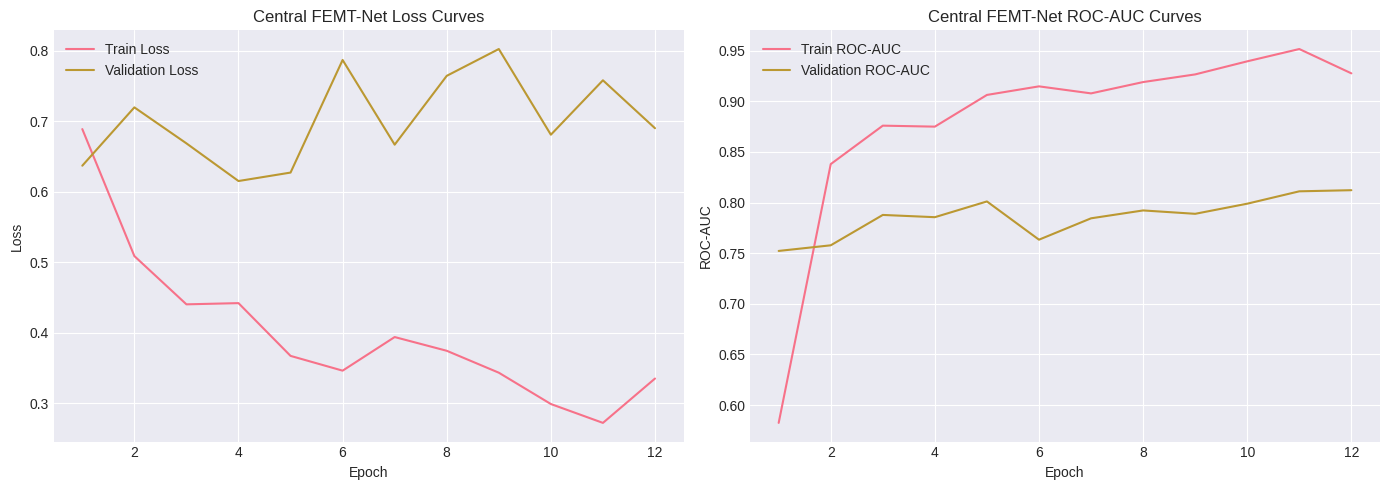

In [7]:
central_model = create_femtnet()
optimizer = torch.optim.Adam(central_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

num_epochs = 12
central_history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_state = copy.deepcopy(central_model.state_dict())
best_val_auc = -np.inf

for epoch in range(num_epochs):
    train_loss, train_metrics = run_epoch(central_model, train_loader, optimizer)
    val_loss, val_metrics = run_epoch(central_model, test_loader, optimizer=None)
    scheduler.step(val_loss)

    central_history['train_loss'].append(train_loss)
    central_history['val_loss'].append(val_loss)
    central_history['train_auc'].append(train_metrics['roc_auc'])
    central_history['val_auc'].append(val_metrics['roc_auc'])

    if np.nan_to_num(val_metrics['roc_auc'], nan=-1.0) > best_val_auc:
        best_val_auc = np.nan_to_num(val_metrics['roc_auc'], nan=-1.0)
        best_state = copy.deepcopy(central_model.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train AUC: {train_metrics['roc_auc']:.4f} | Val AUC: {val_metrics['roc_auc']:.4f}"
    )

best_central_model = create_femtnet()
best_central_model.load_state_dict(best_state)
central_true, central_prob, central_modality_weights = predict_with_model(best_central_model, test_loader)
central_results = compute_binary_metrics(central_true, central_prob)

print("\n✅ Centralized FEMT-Net evaluation")
for metric_name, metric_value in central_results.items():
    print(f"   {metric_name}: {metric_value:.4f}")

plot_training_history(central_history, title='Central FEMT-Net')

## 🔐 STEP 8: Federated Learning with Weighted FedAvg

This stage simulates a cross-silo hospital setting:
- local training happens inside each hospital/client
- only model parameters are shared
- global parameters are aggregated using weighted FedAvg based on client sample counts

In [8]:
def make_client_subsets(dataset, num_clients=3):
    shuffled_indices = np.random.permutation(len(dataset))
    split_indices = np.array_split(shuffled_indices, num_clients)
    return [Subset(dataset, idx.tolist()) for idx in split_indices if len(idx) > 0]

def weighted_fedavg(state_dicts, weights):
    total_weight = float(sum(weights))
    averaged = {}
    for key in state_dicts[0].keys():
        accumulator = None
        for state_dict, weight in zip(state_dicts, weights):
            value = state_dict[key].detach().clone().float() * (weight / total_weight)
            accumulator = value if accumulator is None else accumulator + value
        averaged[key] = accumulator.type_as(state_dicts[0][key])
    return averaged

num_clients = 3
federated_rounds = 5
local_epochs = 2
client_subsets = make_client_subsets(train_dataset, num_clients=num_clients)

federated_model = create_femtnet()
federated_history = []

for round_idx in range(federated_rounds):
    local_states = []
    local_weights = []

    for client_id, client_subset in enumerate(client_subsets, start=1):
        local_model = copy.deepcopy(federated_model)
        local_optimizer = torch.optim.Adam(local_model.parameters(), lr=1e-3, weight_decay=1e-5)
        client_loader = DataLoader(client_subset, batch_size=batch_size, shuffle=True)

        for _ in range(local_epochs):
            run_epoch(local_model, client_loader, local_optimizer)

        local_states.append(copy.deepcopy(local_model.state_dict()))
        local_weights.append(len(client_subset))
        print(f"Round {round_idx + 1} | Client {client_id} finished local training on {len(client_subset)} samples")

    global_state = weighted_fedavg(local_states, local_weights)
    federated_model.load_state_dict(global_state)
    _, round_metrics = run_epoch(federated_model, test_loader, optimizer=None)
    federated_history.append(round_metrics)
    print(f"✅ After round {round_idx + 1}: test ROC-AUC = {round_metrics['roc_auc']:.4f}, test F1 = {round_metrics['f1']:.4f}")

federated_true, federated_prob, federated_modality_weights = predict_with_model(federated_model, test_loader)
federated_results = compute_binary_metrics(federated_true, federated_prob)

print("\n✅ Federated FEMT-Net evaluation")
for metric_name, metric_value in federated_results.items():
    print(f"   {metric_name}: {metric_value:.4f}")

Round 1 | Client 1 finished local training on 80 samples
Round 1 | Client 2 finished local training on 80 samples
Round 1 | Client 3 finished local training on 80 samples
✅ After round 1: test ROC-AUC = 0.6578, test F1 = 0.0000
Round 2 | Client 1 finished local training on 80 samples
Round 2 | Client 2 finished local training on 80 samples
Round 2 | Client 3 finished local training on 80 samples
✅ After round 2: test ROC-AUC = 0.7278, test F1 = 0.5652
Round 3 | Client 1 finished local training on 80 samples
Round 3 | Client 2 finished local training on 80 samples
Round 3 | Client 3 finished local training on 80 samples
✅ After round 3: test ROC-AUC = 0.7622, test F1 = 0.7188
Round 4 | Client 1 finished local training on 80 samples
Round 4 | Client 2 finished local training on 80 samples
Round 4 | Client 3 finished local training on 80 samples
✅ After round 4: test ROC-AUC = 0.7511, test F1 = 0.6786
Round 5 | Client 1 finished local training on 80 samples
Round 5 | Client 2 finished loc

## 🔍 STEP 9: Explainability, Evaluation, Saving, and Inference

This final section covers:
- quantitative comparison of centralized and federated FEMT-Net
- confusion matrices and ROC curves
- modality contribution visualization
- ECG saliency via a Grad-CAM-style 1D method
- SHAP over a clinical-feature surrogate model
- saving reusable artifacts and defining an inference function

                   accuracy precision  recall      f1 roc_auc
Model                                                        
Central FEMT-Net     0.7167    0.6857  0.8000  0.7385  0.8122
Federated FEMT-Net   0.6833    0.6897  0.6667  0.6780  0.7644


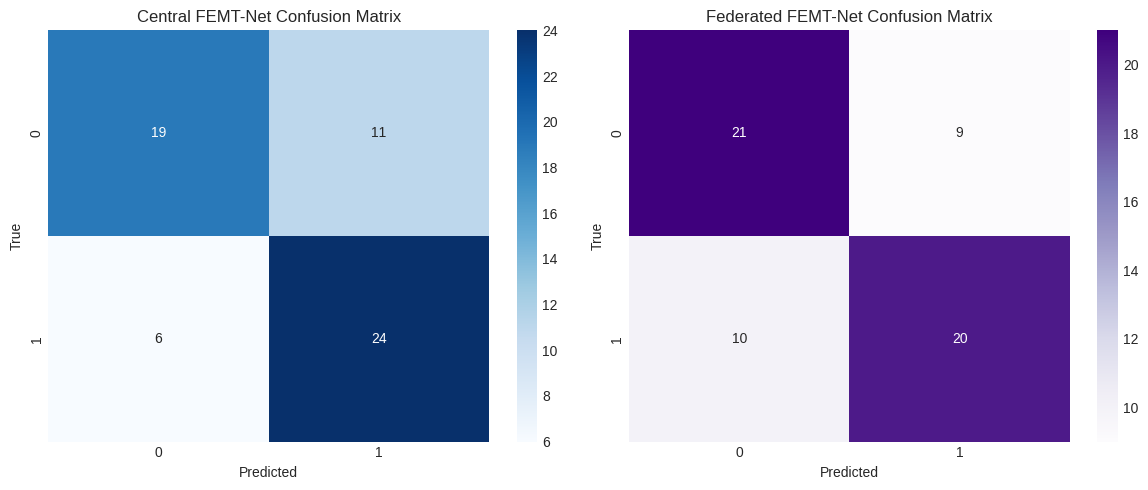

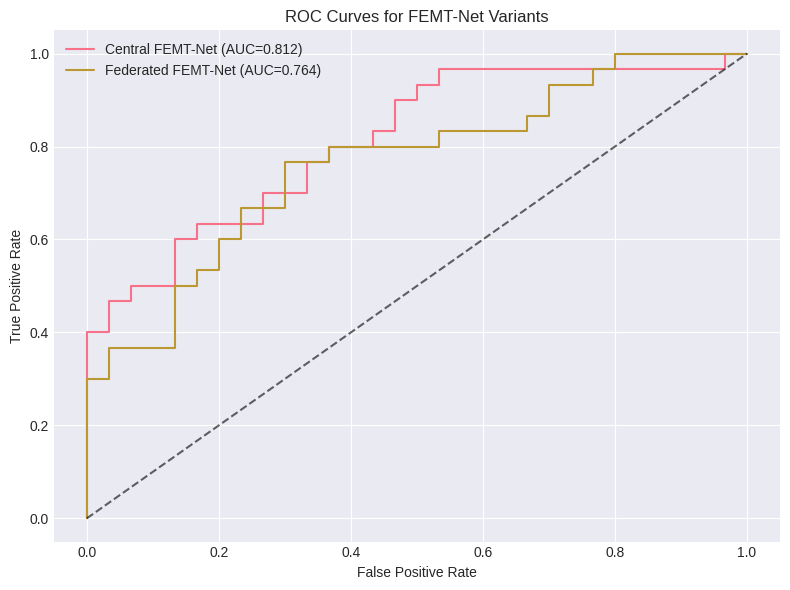

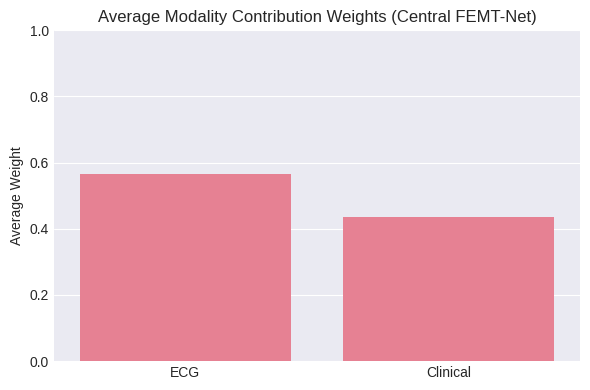

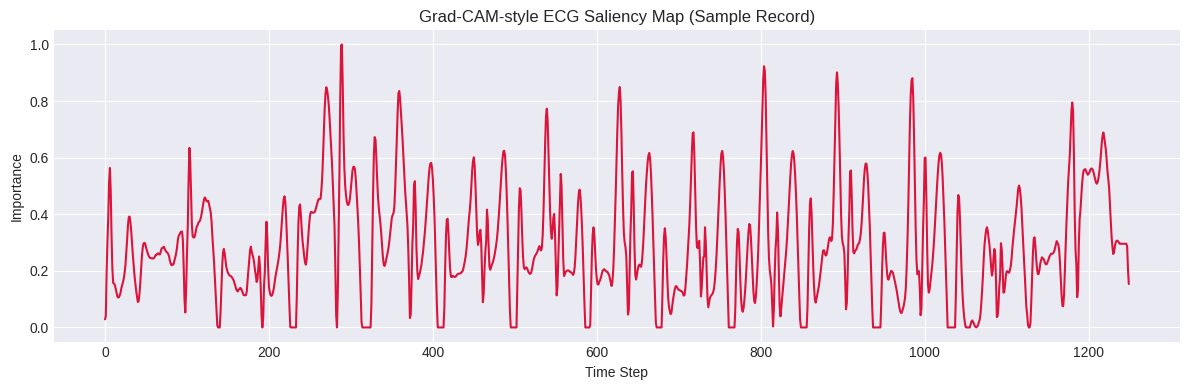

<Figure size 1000x600 with 0 Axes>

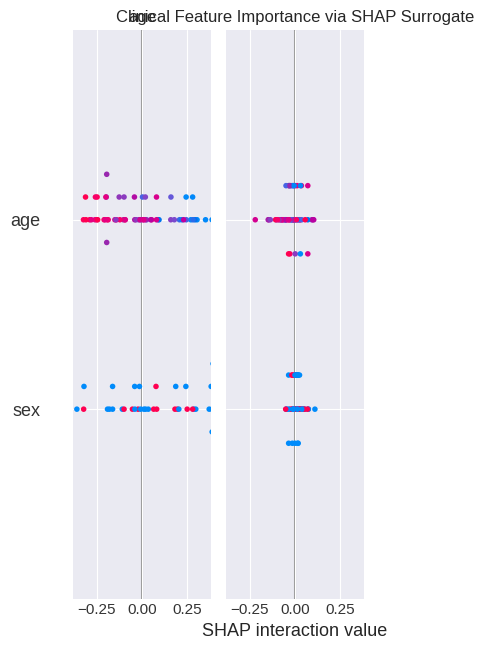


🔮 Example multimodal prediction
{'prediction': 0, 'probability': 0.056712787598371506, 'ecg_weight': 0.5677279829978943, 'clinical_weight': 0.4322720468044281}

✅ FEMT-Net notebook rewrite complete and aligned with the document architecture.


In [9]:
comparison_df = pd.DataFrame([
    {'Model': 'Central FEMT-Net', **central_results},
    {'Model': 'Federated FEMT-Net', **federated_results},
]).set_index('Model')
print(comparison_df.applymap(lambda value: f"{value:.4f}" if isinstance(value, float) else value))

central_pred = (central_prob >= 0.5).astype(int)
federated_pred = (federated_prob >= 0.5).astype(int)

_, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(central_true, central_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Central FEMT-Net Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(confusion_matrix(federated_true, federated_pred), annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title('Federated FEMT-Net Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for model_name, y_true, y_prob in [('Central FEMT-Net', central_true, central_prob), ('Federated FEMT-Net', federated_true, federated_prob)]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6)
plt.title('ROC Curves for FEMT-Net Variants')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

avg_modality_weights = central_modality_weights.mean(axis=0)
plt.figure(figsize=(6, 4))
sns.barplot(x=['ECG', 'Clinical'], y=avg_modality_weights)
plt.title('Average Modality Contribution Weights (Central FEMT-Net)')
plt.ylabel('Average Weight')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._save_activations)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, _module, _inputs, output):
        self.activations = output.detach()

    def _save_gradients(self, _module, _grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, ecg_tensor, clinical_tensor):
        self.model.eval()
        self.model.zero_grad()
        logits, _, _ = self.model(ecg_tensor, clinical_tensor)
        logits.backward(torch.ones_like(logits))
        weights = self.gradients.mean(dim=2, keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1)).squeeze(0)
        cam = cam.cpu().numpy()
        cam = cam / (cam.max() + 1e-6)
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

sample_index = 0
sample_ecg_tensor = torch.tensor(test_ecg[sample_index:sample_index + 1], dtype=torch.float32, device=device)
sample_clinical_tensor = torch.tensor(test_clinical_scaled[sample_index:sample_index + 1], dtype=torch.float32, device=device)
gradcam = GradCAM1D(best_central_model, best_central_model.ecg_encoder.conv3)
ecg_saliency = gradcam.generate(sample_ecg_tensor, sample_clinical_tensor)
gradcam.close()

plt.figure(figsize=(12, 4))
plt.plot(ecg_saliency, color='crimson')
plt.title('Grad-CAM-style ECG Saliency Map (Sample Record)')
plt.xlabel('Time Step')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

surrogate_model = RandomForestClassifier(n_estimators=200, random_state=42)
surrogate_model.fit(train_clinical_scaled, train_labels.astype(int))
try:
    clinical_explainer = shap.TreeExplainer(surrogate_model)
    shap_values = clinical_explainer.shap_values(test_clinical_scaled[:100])
    shap_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_to_plot, test_clinical_scaled[:100], feature_names=clinical_feature_names, plot_type='bar', show=False)
    plt.title('Clinical Feature Importance via SHAP Surrogate')
    plt.tight_layout()
    plt.show()
except Exception as shap_error:
    print(f"⚠️ SHAP visualization skipped: {shap_error}")

os.makedirs('models', exist_ok=True)
torch.save({
    'state_dict': best_central_model.state_dict(),
    'num_leads': num_leads,
    'clinical_dim': train_clinical_scaled.shape[1],
    'signal_length': signal_length,
    'clinical_feature_names': clinical_feature_names,
    'results': central_results
}, 'models/femtnet_central.pth')

torch.save({
    'state_dict': federated_model.state_dict(),
    'num_leads': num_leads,
    'clinical_dim': train_clinical_scaled.shape[1],
    'signal_length': signal_length,
    'clinical_feature_names': clinical_feature_names,
    'results': federated_results
}, 'models/femtnet_federated.pth')

with open('models/clinical_imputer.pkl', 'wb') as file_obj:
    pickle.dump(clinical_imputer, file_obj)
with open('models/clinical_scaler.pkl', 'wb') as file_obj:
    pickle.dump(clinical_scaler, file_obj)
with open('models/clinical_feature_names.pkl', 'wb') as file_obj:
    pickle.dump(clinical_feature_names, file_obj)

def prepare_ecg_signal(ecg_signal, expected_leads=num_leads, expected_length=signal_length):
    ecg_signal = np.asarray(ecg_signal, dtype=np.float32)
    if ecg_signal.ndim != 2:
        raise ValueError('ECG signal must be a 2D array with shape [leads, time] or [time, leads].')
    if ecg_signal.shape[0] != expected_leads and ecg_signal.shape[1] == expected_leads:
        ecg_signal = ecg_signal.T
    if ecg_signal.shape[0] != expected_leads:
        raise ValueError(f'Expected {expected_leads} ECG leads but received shape {ecg_signal.shape}.')
    if ecg_signal.shape[1] >= expected_length:
        ecg_signal = ecg_signal[:, :expected_length]
    else:
        pad_width = expected_length - ecg_signal.shape[1]
        ecg_signal = np.pad(ecg_signal, ((0, 0), (0, pad_width)), mode='constant')
    return ecg_signal.astype(np.float32)

def prepare_clinical_vector(clinical_input):
    if isinstance(clinical_input, dict):
        vector = np.array([[clinical_input.get(feature_name, np.nan) for feature_name in clinical_feature_names]], dtype=np.float32)
    else:
        vector = np.asarray(clinical_input, dtype=np.float32).reshape(1, -1)
    vector = clinical_imputer.transform(vector)
    vector = clinical_scaler.transform(vector)
    return vector.astype(np.float32)

def predict_cardiovascular_risk(ecg_signal, clinical_input, use_federated=False):
    model = federated_model if use_federated else best_central_model
    model.eval()
    prepared_ecg = prepare_ecg_signal(ecg_signal)
    prepared_clinical = prepare_clinical_vector(clinical_input)

    ecg_tensor = torch.tensor(prepared_ecg[None, ...], dtype=torch.float32, device=device)
    clinical_tensor = torch.tensor(prepared_clinical, dtype=torch.float32, device=device)

    with torch.no_grad():
        logits, modality_weights, _ = model(ecg_tensor, clinical_tensor)
        probability = torch.sigmoid(logits).item()

    prediction = int(probability >= 0.5)
    contribution = modality_weights.cpu().numpy()[0]
    return {
        'prediction': prediction,
        'probability': probability,
        'ecg_weight': float(contribution[0]),
        'clinical_weight': float(contribution[1])
    }

example_result = predict_cardiovascular_risk(test_ecg[0], test_clinical_raw.iloc[0].to_dict(), use_federated=False)
print("\n🔮 Example multimodal prediction")
print(example_result)
print("\n✅ FEMT-Net notebook rewrite complete and aligned with the document architecture.")